[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **AI Powered Yoga Pose Classification & Form Analysis**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview

This is a real-time computer vision system that detects, classifies, and evaluates yoga poses using a custom-trained **YOLO11 Pose** model. The system tracks body keypoints, analyzes joint angles, and provides instant feedback on pose accuracy and hold duration.

The model is trained to recognize and analyze five yoga asanas:

- **Compass Pose (Parivrtta Surya Yantrasana)**
- **Revolved Head-to-Knee Pose (Parivrtta Janu Sirsasana)**
- **Seated Forward Bend (Paschimottanasana)**
- **Lotus Pose (Padmasana)**
- **Accomplished Pose (Siddhasana)**

Unlike conventional pose estimation frameworks, the custom model is specifically trained for yoga movements, enabling reliable keypoint detection even during poses involving self-occlusion, body rotations, and extreme flexibility.

The pipeline combines **YOLO11 pose estimation**, **geometric joint-angle analysis**, and **rule-based pose classification** to accurately identify yoga postures, verify body alignment, measure pose hold duration, and provide real-time feedback through an interactive on-screen dashboard.

---

## Core Architecture

- **YOLO11 Pose Estimation** for body keypoint detection.
- **Joint Angle Analysis** to evaluate posture accuracy.
- **Pose Classification** using body geometry and spatial relationships.
- **Live HUD** displaying pose name, joint angles, posture feedback, and hold duration.

---

## Real-World Applications

### Virtual Yoga Coach
Provides real-time posture correction and guided practice using a webcam or mobile camera.

### Physical Therapy
Assists rehabilitation by monitoring exercise quality and tracking patient recovery remotely.

### Smart Fitness Mirrors
Enables automated yoga coaching and performance analytics in gyms and home fitness systems.

### Fitness Video Analytics
Automatically identifies and timestamps yoga poses within recorded workout videos for indexing and content organization.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [1]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [ ]:
%pip install tqdm

from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['Yoga Dataset.mp4'],
    total_images=50,
    out_dir="dataset_Frames",
    jpg_quality=100,
    seed=42
)


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
[✓] Extracted 20 frames to folder: dataset_Frames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [6]:
import json
import os
import random
from pathlib import Path

# Configuration - Updated image source path to your folder
JSON_PATH = 'a4241522-634a-45ea-a189-7f7f4a4a9505.json'
DATASET_ROOT = './yoloDataset'
IMAGE_SOURCE_DIR = './dataset_Frames'  # Points directly to your images folder

def setup_directories(root):
    """Creates the exact folder structure required by YOLO."""
    splits = ['train', 'val', 'test']
    for split in splits:
        os.makedirs(os.path.join(root, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(root, 'labels', split), exist_ok=True)

def convert_and_split(json_path, root_dir, img_src_dir, train_ratio=0.6, val_ratio=0.2):
    setup_directories(root_dir)

    # Load Labellerr export JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)

    images_list = data['images']
    
    # Shuffle to ensure a random distribution across splits
    random.seed(42)  
    random.shuffle(images_list)

    # Group annotations by image_id
    annotations_by_img = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_img:
            annotations_by_img[img_id] = []
        annotations_by_img[img_id].append(ann)

    total_images = len(images_list)
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)

    for idx, img_info in enumerate(images_list):
        # Determine split assignment
        if idx < train_end:
            split = 'train'
        elif idx < val_end:
            split = 'val'
        else:
            split = 'test'

        img_w = img_info['width']
        img_h = img_info['height']
        file_name = img_info['file_name']

        txt_name = Path(file_name).with_suffix('.txt')
        
        target_img_path = os.path.join(root_dir, 'images', split, file_name)
        target_txt_path = os.path.join(root_dir, 'labels', split, txt_name)

        # 1. Move image from dataset_Frames folder to the new split folder
        source_img_path = os.path.join(img_src_dir, file_name)
        if os.path.exists(source_img_path):
            os.replace(source_img_path, target_img_path)
        else:
            print(f"Warning: Image {file_name} not found in '{img_src_dir}'. Only creating text label.")

        # 2. Convert and build the YOLO label lines
        annotations = annotations_by_img.get(img_info['id'], [])
        yolo_lines = []

        for ann in annotations:
            x_min, y_min, box_w, box_h = ann['bbox']
            x_center = (x_min + box_w / 2) / img_w
            y_center = (y_min + box_h / 2) / img_h
            norm_box_w = box_w / img_w
            norm_box_h = box_h / img_h

            class_idx = 0  # 'Body' maps to 0

            line_elements = [
                f"{class_idx}",
                f"{x_center:.6f}",
                f"{y_center:.6f}",
                f"{norm_box_w:.6f}",
                f"{norm_box_h:.6f}"
            ]

            kp_list = ann['keypoints']
            for i in range(0, len(kp_list), 3):
                kp_x = kp_list[i]
                kp_y = kp_list[i+1]
                kp_v = kp_list[i+2]

                norm_kp_x = kp_x / img_w if kp_v > 0 else 0.0
                norm_kp_y = kp_y / img_h if kp_v > 0 else 0.0
                line_elements.extend([f"{norm_kp_x:.6f}", f"{norm_kp_y:.6f}", f"{int(kp_v)}"])

            yolo_lines.append(" ".join(line_elements))

        # Write label text file
        with open(target_txt_path, 'w') as out_file:
            out_file.write("\n".join(yolo_lines))

    print(f"Dataset successfully created and split into {root_dir}!")

if __name__ == '__main__':
    convert_and_split(JSON_PATH, DATASET_ROOT, IMAGE_SOURCE_DIR)

Dataset successfully created and split into ./yoloDataset!


# Load and Train YOLO Pose Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
from ultralytics import YOLO

# 1. Load the pre-trained YOLO11 Large Pose model
# This automatically handles custom configurations defined in your data.yaml
model = YOLO('yolo11l-pose.pt') 

# 2. Kick off the training process on your dataset
model.train(
    data='/kaggle/working/data.yaml',    # Path to your data.yaml file in Kaggle
    epochs=100,                          # Number of training epochs
    imgsz=640,                           # Image size (YOLO standard pixel resolution)
    batch=16,                            # Batch size (adjust down to 8 if you hit GPU memory limits)
    project='/kaggle/working/factory',   # Directory where training logs/weights are saved
    name='train_run_11',                 # Name of this specific training execution run
    device=0                             # Uses the primary GPU (Kaggle T4 or P100)
)

# Code Review: Single-Frame Yoga Pose Inference

## Overview

This script performs single-frame inference using a custom-trained **YOLO11 Pose** model. It extracts the final frame from a video, predicts body keypoints, overlays the detected skeleton, and visualizes the result using Matplotlib.

---

## Core Components

### Model Initialization
Loads the custom `best.pt` YOLO11 Pose model to detect body keypoints for yoga pose analysis.

### YOLO11 Pose Inference
Runs the selected frame through the custom model with a confidence threshold of **0.3** to generate body keypoint predictions.

### Skeleton Visualization
Uses the native `result.plot()` function to render body keypoints and skeletal connections while hiding bounding boxes for a cleaner visualization.

### Image Rendering
Converts the annotated frame from **BGR** to **RGB** and displays the final output using Matplotlib with hidden axes for presentation-quality visualization.

---

Target localized on the last frame (Frame 901)! Plotting coordinate maps...


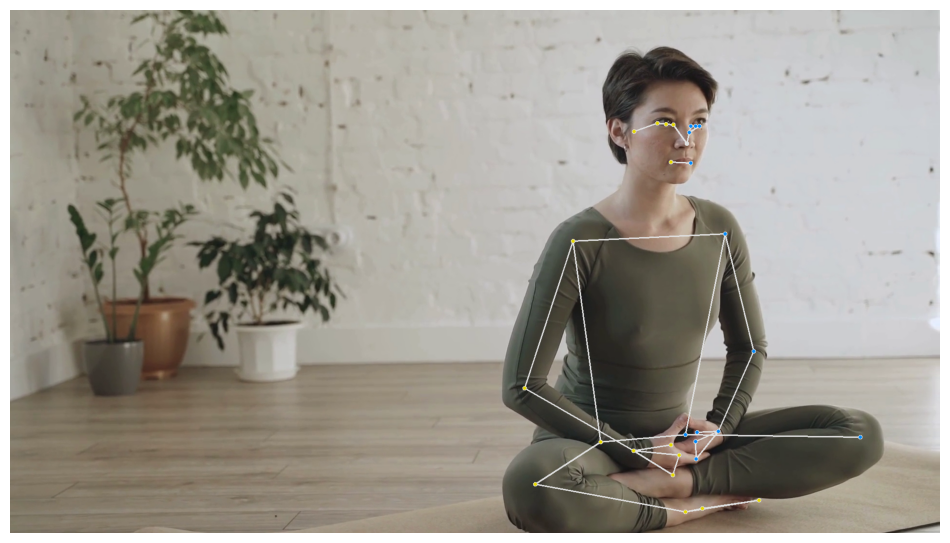

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Configuration
VIDEO_PATH = 'Yoga Dataset.mp4'
MODEL_PATH = 'best.pt'  # Path to your custom-trained weights file

def run_custom_yolo_pose(video_path, model_path):
    # 1. Load your custom trained YOLO11 Pose model
    model = YOLO(model_path)

    # 2. Open video capture stream
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return

    # Get total frame count from metadata
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Jump directly to the index of the absolute last frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames - 1)
    
    # Extract the target last frame
    success, frame = cap.read()
    cap.release()

    if not success:
        print("Error: Could not read the last frame.")
        return

    # 3. Perform prediction on the raw frame
    # conf=0.3 sets the threshold, device=0 enforces GPU usage if available
    results = model.predict(source=frame, conf=0.3, verbose=False)
    result = results[0]  # Grab prediction arrays for the single image frame

    # 4. Check if any body skeleton structures were localized
    if result.keypoints is not None and len(result.keypoints.xy) > 0:
        print(f"Target localized by custom YOLO model on the last frame (Frame {total_frames})!")
        
        # Plot predictions using standard YOLO rendering configurations
        # line_width=2 sets skeletal lines to a thin profile
        # boxes=False hides the bounding box rectangle so only the pose is visible
        annotated_frame = result.plot(
            boxes=False,
            kpt_line=True,
            line_width=2
        )
    else:
        print("Custom model did not detect any keypoints on the last frame.")
        annotated_frame = frame

    # 5. Convert final output display matrix from BGR to RGB for correct matplotlib colors
    final_output = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # Render out final canvas
    plt.figure(figsize=(12, 8))
    plt.imshow(final_output)
    plt.axis('off')
    plt.title("Custom YOLO11-Pose Last Frame Prediction")
    plt.show()

if __name__ == '__main__':
    run_custom_yolo_pose(VIDEO_PATH, MODEL_PATH)

# YOLO11-Pose Video Inference Pipeline

This script implements an end-to-end video inference pipeline using a custom-trained **YOLO11 Pose** model. It processes an input video frame-by-frame, predicts body keypoints, overlays the detected skeleton, and exports the annotated results as a high-quality MP4 video.

---

## Core Components

### Model & Video Initialization
Loads the custom `best.pt` model, opens the input video, and retrieves its native frame rate, width, and height to preserve the original video properties.

### Output Video Configuration
Initializes a `cv2.VideoWriter` using the **mp4v** codec to generate an output video with matching resolution and FPS.

### Frame-by-Frame Inference
Reads each frame sequentially and performs pose estimation using `model.predict()` with a confidence threshold of **0.5** to filter low-confidence detections.

### Pose Visualization
Uses the native `result.plot()` method to render body keypoints and skeletal connections while suppressing bounding boxes for a cleaner visual output.

### Video Export
Writes each annotated frame to the output stream and safely releases all video resources after processing is complete.

---

In [ ]:
import cv2
from ultralytics import YOLO

# Configuration
INPUT_VIDEO_PATH = 'Yoga Dataset.mp4'
OUTPUT_VIDEO_PATH = 'Yoga_Tracked_Output.mp4'
MODEL_PATH = 'best.pt'  # Path to your custom-trained weights file

def run_custom_yolo_video_inference(input_path, output_path, model_path):
    # 1. Load your custom trained YOLO11 Pose model
    model = YOLO(model_path)

    # 2. Initialize Video Capture
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Error: Cannot open input video {input_path}")
        return

    # Extract source video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 3. Initialize Video Writer for MP4 Saving
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print(f"Processing {total_frames} frames using YOLO11-Pose. Saving output to: {output_path}...")
    frame_idx = 0

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break  # End of video stream

        # 4. Perform prediction directly on the native BGR frame
        # conf=0.5 defines baseline detection confidence
        # verbose=False cleans up console logs for speed optimization
        results = model.predict(source=frame, conf=0.5, verbose=False)
        result = results[0]

        # 5. Check if keypoints were localized and plot them
        if result.keypoints is not None and len(result.keypoints.xy) > 0:
            # boxes=False hides the bounding box rectangle so only the pose skeleton is shown
            # kpt_line=True enables rendering of internal connecting lines
            # line_width=2 keeps structural overlays clean and sharp
            annotated_frame = result.plot(
                boxes=False,
                kpt_line=True,
                line_width=2
            )
        else:
            # Fallback to the untouched native frame if tracking drops temporarily
            annotated_frame = frame

        # 6. Write the processed BGR array matrix directly into the pipeline
        out.write(annotated_frame)
        
        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"Progress: Completed frame {frame_idx}/{total_frames}")

    # Release file stream system locks
    cap.release()
    out.release()
    print("Inference complete! Processing finished successfully.")

if __name__ == '__main__':
    run_custom_yolo_video_inference(INPUT_VIDEO_PATH, OUTPUT_VIDEO_PATH, MODEL_PATH)

Processing 901 frames. Saving output to: Yoga_Tracked_Output.mp4...
Progress: Completed frame 30/901
Progress: Completed frame 60/901
Progress: Completed frame 90/901
Progress: Completed frame 120/901
Progress: Completed frame 150/901
Progress: Completed frame 180/901
Progress: Completed frame 210/901
Progress: Completed frame 240/901
Progress: Completed frame 270/901
Progress: Completed frame 300/901
Progress: Completed frame 330/901
Progress: Completed frame 360/901
Progress: Completed frame 390/901
Progress: Completed frame 420/901
Progress: Completed frame 450/901
Progress: Completed frame 480/901
Progress: Completed frame 510/901
Progress: Completed frame 540/901
Progress: Completed frame 570/901
Progress: Completed frame 600/901
Progress: Completed frame 630/901
Progress: Completed frame 660/901
Progress: Completed frame 690/901
Progress: Completed frame 720/901
Progress: Completed frame 750/901
Progress: Completed frame 780/901
Progress: Completed frame 810/901
Progress: Complet

# Intelligent Yoga Analytics Pipeline

This script implements an end-to-end yoga pose analysis pipeline using a custom-trained **YOLO11 Pose** model. It processes a video frame-by-frame, estimates body keypoints, computes joint angles, classifies yoga poses using geometric rules, tracks pose duration, and renders a real-time analytics dashboard.

---

## Core Components

### YOLO11 Pose Estimation
Loads the custom `best.pt` model to detect 17 body keypoints and continuously track the practitioner's posture throughout the video.

### Joint Angle Calculation
Computes joint angles using vector geometry (`arctan2`), where the middle point acts as the joint vertex. The calculated angle is normalized to the **0°–180°** range, providing stable measurements for pose analysis.

### Frame-by-Frame Inference
Processes each frame using `model.predict()` with a confidence threshold of **0.4** and generates body keypoints with native YOLO skeleton visualization.

### Pose Classification Engine
Combines joint angles with spatial relationships to classify yoga poses while reducing false detections caused by camera viewpoints and body occlusions.

### Hold Duration Tracking
Measures pose duration using the video's FPS and frame count, ensuring frame-accurate timing independent of processing speed.

### Live Visualization
Displays the predicted skeleton, detected pose, joint angle measurements, hold timer, and a real-time HUD on the output video.

---

## Angle Logic

The classifier calculates angles using three body keypoints, where the middle point represents the joint being evaluated.

Examples include:

- **Hip Angle:** Shoulder → Hip → Knee
- **Knee Angle:** Hip → Knee → Ankle
- **Elbow Angle:** Shoulder → Elbow → Wrist
- **Shoulder Angle:** Hip → Shoulder → Elbow

These angles are combined with positional constraints to accurately distinguish between different yoga poses.

---

## Pose Classification Logic

### Compass Pose
- Detects if either ankle rises above the corresponding hip.
- Confirms the pose using a large hip abduction angle (**>120°**) to identify the vertical split.

### Revolved Side Stretch
- Computes the shoulder line inclination relative to a horizontal reference.
- Classifies the pose when the torso tilt exceeds approximately **35°**, indicating deep lateral flexion.

### Forward Bend (Paschimottanasana)
- Requires:
  - Hip angle **<45°**
  - Knee angle **>155°**
  - Feet remaining on the ground
- These constraints distinguish a seated forward fold from other bent-body postures.

### Lotus Pose (Dhyana Mudra)
- Checks that the head remains centered over the hips.
- Verifies both wrists are positioned below the chest and close together, indicating the meditation mudra.

### Accomplished Pose (Siddhasana)
- Detects an upright spine with a centered head position.
- Confirms the wrists are widely separated, representing relaxed hands resting on the knees.

---

## Output

The pipeline exports an annotated MP4 video containing:

- YOLO11 body skeleton
- Detected yoga pose
- Live joint angle measurements
- Pose hold duration
- Interactive analytics dashboard

---

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# Configuration
INPUT_VIDEO_PATH = 'Yoga Dataset.mp4'
OUTPUT_VIDEO_PATH = 'Yoga_Inference_HUD.mp4'
MODEL_PATH = 'best.pt'  # Path to your custom-trained weights file

def calculate_angle(a, b, c):
    """
    Calculates the 2D plane angle between three joints.
    b is the vertex point. coordinates are arrays [x, y].
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360.0 - angle
        
    return angle

def classify_pose(kpts_xy, img_width, img_height):
    """
    Translates YOLO pose indices into angles and classifications.
    YOLO Keypoint Indices:
    0: Nose, 5: L_Shoulder, 6: R_Shoulder, 7: L_Elbow, 8: R_Elbow, 
    9: L_Wrist, 10: R_Wrist, 11: L_Hip, 12: R_Hip, 13: L_Knee, 
    14: R_Knee, 15: L_Ankle, 16: R_Ankle
    """
    # Extract structural normalized coordinates [x, y] by dividing by dimensions
    # to maintain compatibility with your original normalized heuristics thresholds
    nose = [kpts_xy[0][0] / img_width, kpts_xy[0][1] / img_height]
    
    l_shoulder = [kpts_xy[5][0] / img_width, kpts_xy[5][1] / img_height]
    r_shoulder = [kpts_xy[6][0] / img_width, kpts_xy[6][1] / img_height]
    l_elbow = [kpts_xy[7][0] / img_width, kpts_xy[7][1] / img_height]
    r_elbow = [kpts_xy[8][0] / img_width, kpts_xy[8][1] / img_height]
    l_wrist = [kpts_xy[9][0] / img_width, kpts_xy[9][1] / img_height]
    r_wrist = [kpts_xy[10][0] / img_width, kpts_xy[10][1] / img_height]
    
    l_hip = [kpts_xy[11][0] / img_width, kpts_xy[11][1] / img_height]
    r_hip = [kpts_xy[12][0] / img_width, kpts_xy[12][1] / img_height]
    l_knee = [kpts_xy[13][0] / img_width, kpts_xy[13][1] / img_height]
    r_knee = [kpts_xy[14][0] / img_width, kpts_xy[14][1] / img_height]
    l_ankle = [kpts_xy[15][0] / img_width, kpts_xy[15][1] / img_height]
    r_ankle = [kpts_xy[16][0] / img_width, kpts_xy[16][1] / img_height]

    # Calculate basic joint angles
    left_hip_flex = calculate_angle(l_shoulder, l_hip, l_knee)
    right_hip_flex = calculate_angle(r_shoulder, r_hip, r_knee)
    left_knee_ext = calculate_angle(l_hip, l_knee, l_ankle)
    right_knee_ext = calculate_angle(r_hip, r_knee, r_ankle)
    
    left_elbow_fold = calculate_angle(l_shoulder, l_elbow, l_wrist)
    right_elbow_fold = calculate_angle(r_shoulder, r_elbow, r_wrist)
    
    # Calculate specialized vertical tracking structures
    mid_hip = [(l_hip[0] + r_hip[0])/2, (l_hip[1] + r_hip[1])/2]
    mid_shoulder = [(l_shoulder[0] + r_shoulder[0])/2, (l_shoulder[1] + r_shoulder[1])/2]
    
    # Proximity metrics
    wrist_dist = np.linalg.norm(np.array(l_wrist) - np.array(r_wrist))

    # --- INFERENCE BLOCKS WITH POSITION SAFEGUARDS ---

    # 1. Compass Pose Check
    ankle_raised = (l_ankle[1] < l_hip[1]) or (r_ankle[1] < r_hip[1])
    if ankle_raised:
        split_angle_l = calculate_angle(r_hip, l_hip, l_ankle)
        split_angle_r = calculate_angle(l_hip, r_hip, r_ankle)
        if split_angle_l > 120 or split_angle_r > 120:
            target_joint = 11 if split_angle_l > split_angle_r else 12
            return "Compass Pose", {target_joint: max(split_angle_l, split_angle_r)}

    # 2. Revolved Head-to-Knee Pose Check
    shoulder_vector_angle = calculate_angle(l_shoulder, r_shoulder, [r_shoulder[0] + 1.0, r_shoulder[1]])
    if (left_hip_flex < 80 or right_hip_flex < 80) and (shoulder_vector_angle > 35) and not ankle_raised:
        if mid_shoulder[1] > mid_hip[1] - 0.2: 
            return "Revolved Side Stretch", {5 if left_hip_flex < right_hip_flex else 6: shoulder_vector_angle}

    # 3. Seated Forward Bend
    if (left_hip_flex < 45 or right_hip_flex < 45) and (left_knee_ext > 155 or right_knee_ext > 155) and not ankle_raised:
        active_angle = left_hip_flex if left_hip_flex < right_hip_flex else right_hip_flex
        return "Forward Bend", {11 if left_hip_flex < right_hip_flex else 12: active_angle}

    # 4. Lotus Pose with Dhyana Mudra (Upright Head Alignment Strategy)
    if wrist_dist < 0.25:
        if l_wrist[1] > mid_shoulder[1] + 0.12 and r_wrist[1] > mid_shoulder[1] + 0.12:
            horizontal_head_drift = abs(nose[0] - mid_hip[0])
            if horizontal_head_drift < 0.08 and nose[1] < mid_shoulder[1]:
                if wrist_dist <= 0.35:
                    # Provide wrist markers (9 and 10 in YOLO mapping)
                    return "Lotus Pose (Mudra)", {9: wrist_dist * 100}

    # 5. Accomplished Pose (Siddhasana)
    if 125 < left_elbow_fold < 179 and 125 < right_elbow_fold < 179:
        if wrist_dist > 0.35:
            return "Accomplished Pose", {7: left_elbow_fold, 8: right_elbow_fold}

    return "Unknown/Transition", {}

def run_yoga_inference(input_path, output_path, model_path):
    # 1. Load Custom Model
    model = YOLO(model_path)

    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        print(f"Error opening video: {input_path}")
        return

    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    # Hold time state tracking variables
    current_pose = "Unknown/Transition"
    pose_frame_counter = 0
    hold_duration = 0.0
    frame_idx = 0

    print(f"Processing {total_frames} frames using Custom YOLO11-Pose...")

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # 2. Run inference on raw frame layout
        results = model.predict(source=frame, conf=0.4, verbose=False)
        result = results[0]

        detected_pose = "Unknown/Transition"
        angles_to_render = {}

        # 3. Process keypoints if found
        if result.keypoints is not None and len(result.keypoints.xy) > 0:
            # Grab absolute pixel coordinates matrix for the first detected person
            kpts_xy = result.keypoints.xy[0].cpu().numpy()
            
            # Verify we have detected all required baseline keypoints (at least 17 structural outputs)
            if len(kpts_xy) >= 17:
                detected_pose, angles_to_render = classify_pose(kpts_xy, width, height)

            # Generate YOLO visual skeleton base overlays
            annotated_frame = result.plot(boxes=False, kpt_line=True, line_width=2)
        else:
            annotated_frame = frame.copy()

        # --- FRAME-ACCURATE TIMING HUD OVERLAY ---
        if detected_pose != "Unknown/Transition":
            if detected_pose == current_pose:
                pose_frame_counter += 1
            else:
                current_pose = detected_pose
                pose_frame_counter = 1
            hold_duration = pose_frame_counter / fps
        else:
            current_pose = "Unknown/Transition"
            pose_frame_counter = 0
            hold_duration = 0.0

        # Render Top Dashboard Panel
        cv2.rectangle(annotated_frame, (10, 10), (420, 110), (30, 30, 30), -1)
        cv2.putText(annotated_frame, f"POSE: {detected_pose}", (20, 45), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(annotated_frame, f"HOLD TIME: {hold_duration:.1f}s", (20, 85), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0) if hold_duration > 0 else (255, 255, 255), 2, cv2.LINE_AA)

        # --- RENDER DYNAMIC TEXT ALONG JOINT COORDINATES ---
        if result.keypoints is not None and len(result.keypoints.xy) > 0 and angles_to_render:
            kpts_xy = result.keypoints.xy[0].cpu().numpy()
            for joint_idx, angle_val in angles_to_render.items():
                if joint_idx < len(kpts_xy):
                    pixel_x, pixel_y = int(kpts_xy[joint_idx][0]), int(kpts_xy[joint_idx][1])
                    
                    # Ensure coordinates don't fall off the screen borders
                    if 0 <= pixel_x < width and 0 <= pixel_y < height:
                        cv2.rectangle(annotated_frame, (pixel_x - 10, pixel_y - 25), (pixel_x + 65, pixel_y + 5), (0, 0, 0), -1)
                        cv2.putText(annotated_frame, f"{int(angle_val)}deg", (pixel_x - 5, pixel_y - 5),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

        # Write out frame to output file channel
        out.write(annotated_frame)
        
        frame_idx += 1
        if frame_idx % 30 == 0:
            print(f"Progress: Completed frame {frame_idx}/{total_frames}")

    cap.release()
    out.release()
    print("Yoga pose classification complete! Video saved with custom YOLO tracking overlays.")

if __name__ == '__main__':
    run_yoga_inference(INPUT_VIDEO_PATH, OUTPUT_VIDEO_PATH, MODEL_PATH)

Yoga pose classification complete! Video saved with HUD overlays.


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
